In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

df = df[['total_bill','tip','sex','smoker','size']]
df = df.dropna()

In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop("smoker", axis=1)
y = df["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [4]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [6]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[29  2]
 [15  3]]


In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.6530612244897959


In [8]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print("Precision:", precision)


Precision: 0.6


In [9]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print("Recall:", recall)


Recall: 0.16666666666666666


In [10]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)


F1 Score: 0.2608695652173913


In [11]:
from sklearn.metrics import classification_report

y_train_pred = model.predict(X_train)

print("Training")
print(classification_report(y_train, y_train_pred))

print("Test")
print(classification_report(y_test, y_pred))


Training
              precision    recall  f1-score   support

           0       0.66      0.93      0.77       120
           1       0.67      0.24      0.35        75

    accuracy                           0.66       195
   macro avg       0.66      0.58      0.56       195
weighted avg       0.66      0.66      0.61       195

Test
              precision    recall  f1-score   support

           0       0.66      0.94      0.77        31
           1       0.60      0.17      0.26        18

    accuracy                           0.65        49
   macro avg       0.63      0.55      0.52        49
weighted avg       0.64      0.65      0.59        49



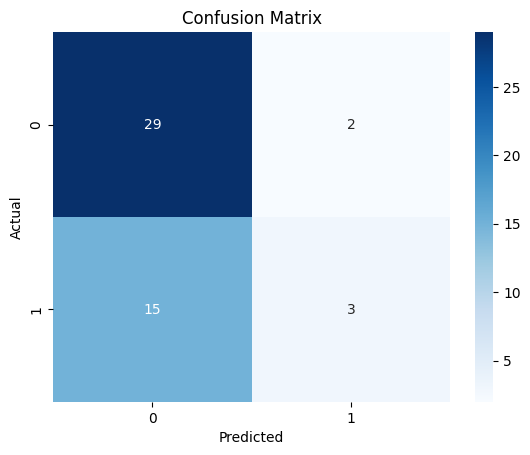

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Scores:", scores)
print("Mean Accuracy:", scores.mean())

Scores: [0.71428571 0.63265306 0.48979592 0.6122449  0.625     ]
Mean Accuracy: 0.6147959183673469


In [14]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5)